In [62]:
# Import libraries
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

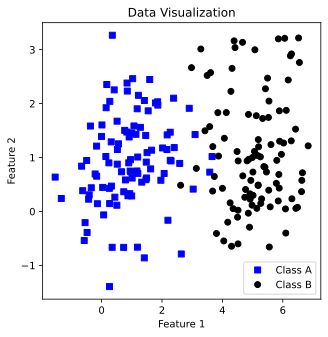

In [63]:
# Create Data

num_samples = 100
blur = 1
A = [1, 1]
B = [5,1]

# generate data
a = [A[0] + np.random.randn(num_samples) *blur, A[1] + np.random.randn(num_samples) *blur]
b = [B[0] + np.random.randn(num_samples) *blur, B[1] + np.random.randn(num_samples) *blur]

# True labels
labels_np = np.vstack((np.zeros((num_samples, 1)), np.ones((num_samples, 1))))

# concatenate into a matrix
data_np = np.hstack((a, b)).T

# Convert to PyTorch tensors
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# Visualize the data
figure = plt.figure(figsize=(5, 5))
plt.plot(data[np.where(labels == 0)[0], 0], data[np.where(labels == 0)[0], 1], 'bs', label='Class A')
plt.plot(data[np.where(labels == 1)[0], 0], data[np.where(labels == 1)[0], 1], 'ko', label='Class B')
plt.title('Data Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [64]:
# Create a model
def create_model(lr):
    Binary_Classification_model = nn.Sequential(
        nn.Linear(2,1),
        nn.ReLU(),
        nn.Linear(1,1),
        # nn.Sigmoid()
    )

    # Loss Function
    # Python recommends not explicitly computing the sigmoid activation function, 
    # but rather using the BCEWithLogitsLoss() function which combines the sigmoid activation 
    # and binary cross-entropy loss in one step for numerical stability.
    loss_fn = nn.BCEWithLogitsLoss()

    # Optimizer
    # The optimizer is simply the flavor of Gradient Decent used. In this case, we are using Stochastic Gradient Descent (SGD).
    optimizer = torch.optim.SGD(Binary_Classification_model.parameters(), lr=lr)

    return Binary_Classification_model, loss_fn, optimizer

    

In [65]:
# Train Mode
num_epochs = 1000

def train_model(model, loss_fn, optimizer):

    # Initialize a list to store the loss values for each epoch
    losses = torch.zeros(num_epochs)

    for epoch in range(num_epochs):

        # Forward pass
        y_hat = model(data)

        # Compute loss
        loss = loss_fn(y_hat, labels)
        losses[epoch] = loss

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Final Foward Pass
        predictions = model(data)

        total_accuracy = 100*torch.mean(((predictions > 0)== labels).float())

    return losses, predictions, total_accuracy


Final Accuracy: 95.5%


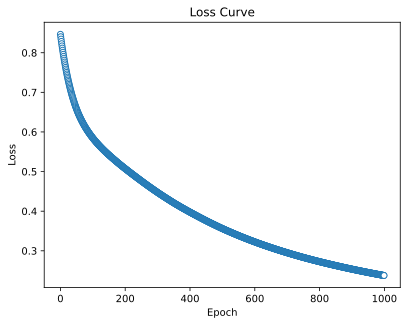

In [66]:

Binary_Classification_model, loss_fn, optimizer = create_model(lr=0.01)

losses, predictions, total_accuracy = train_model(Binary_Classification_model, loss_fn, optimizer)

print('Final Accuracy: %g%%' % total_accuracy.item())


# Visualize the loss curve
plt.plot(losses.detach(), 'o', markerfacecolor='w', linewidth=.1)
plt.xlabel('Epoch'), plt.ylabel('Loss'), plt.title('Loss Curve')
plt.show()